In [2]:
import glob, json, os
from PIL import Image
from tqdm import tqdm_notebook
import numpy as np
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

img_paths = glob.glob('./data/ai_challenger_caption_validation_20170910/caption_validation_images_20170910/*.jpg')
img_paths.sort()

img_paths = img_paths[:3000]
img_paths[:2]

['./data/ai_challenger_caption_validation_20170910/caption_validation_images_20170910\\1.jpg',
 './data/ai_challenger_caption_validation_20170910/caption_validation_images_20170910\\10.jpg']

In [3]:
validation_annotations = json.load(
    open('./data/ai_challenger_caption_validation_20170910/caption_validation_annotations_20170910.json',encoding='utf-8')
)

validation_annotations[:2]

[{'image_id': '1.jpg',
  'caption': ['一束花在森林在跑步，模糊背景。',
   '一位男士在玩耍，周围安静祥和。',
   '特写镜头，一位女士在咖啡厅在跑步。',
   '海边里，一位老人在聊天。',
   '两只鸟在森林在聊天，安静祥和。']},
 {'image_id': '2.jpg',
  'caption': ['办公室里，一只猫在欣赏风景。',
   '黑白调的咖啡厅，一位老人在拍照。',
   '一位女士在工作，周围全景。',
   '一辆车在拍照，周围微风拂面。',
   '特写镜头的花园，一群小孩在欣赏风景。']}]

In [4]:
validation_annotations_dict = {x['image_id']: x['caption'][0] for x in validation_annotations}
print(validation_annotations_dict)

{'1.jpg': '一束花在森林在跑步，模糊背景。', '2.jpg': '办公室里，一只猫在欣赏风景。', '3.jpg': '街道里，一位男士在拍照。', '4.jpg': '厨房里，一群小孩在聊天。', '5.jpg': '一个人在拍照，周围模糊背景。', '6.jpg': '模糊背景的操场，一只猫在散步。', '7.jpg': '阳光明媚，一位女士在厨房在拍照。', '8.jpg': '一群小孩在海边在晒太阳，色彩鲜艳。', '9.jpg': '黑白调的森林，一位老人在工作。', '10.jpg': '特写镜头，一位男士在花园在吃饭。', '11.jpg': '海边里，一束花在玩耍。', '12.jpg': '一位男士在吃饭，周围安静祥和。', '13.jpg': '一个人在欣赏风景，周围黑白调。', '14.jpg': '安静祥和的街道，一辆车在聊天。', '15.jpg': '一群小孩在卧室在拍照，阴雨绵绵。', '16.jpg': '安静祥和，一位老人在办公室在散步。', '17.jpg': '一位男士在森林在拍照，安静祥和。', '18.jpg': '一位男士在跑步，周围微风拂面。', '19.jpg': '一束花在操场在看书，全景。', '20.jpg': '黑白调的森林，一个人在跑步。', '21.jpg': '色彩鲜艳的厨房，一群小孩在吃饭。', '22.jpg': '微风拂面的森林，一个人在欣赏风景。', '23.jpg': '一只狗在咖啡厅在吃饭，模糊背景。', '24.jpg': '阳光明媚的办公室，一个人在玩耍。', '25.jpg': '安静祥和的花园，两只鸟在聊天。', '26.jpg': '色彩鲜艳的公园，一只猫在工作。', '27.jpg': '阳光明媚，一只猫在公园在聊天。', '28.jpg': '热闹非凡，一位男士在卧室在跑步。', '29.jpg': '热闹非凡，一位老人在花园在欣赏风景。', '30.jpg': '一辆车在拍照，周围模糊背景。', '31.jpg': '一位男士在卧室在看书，微风拂面。', '32.jpg': '一个人在卧室在欣赏风景，全景。', '33.jpg': '黑白调，一束花在操场在拍照。', '34.jpg': '海边里，一位女士在晒太阳。', '35.jpg': '森林里，一位女士在吃饭。

In [5]:
img_paths_basenames = [os.path.basename(x) for x in img_paths]
print(img_paths_basenames)
img_captions = [validation_annotations_dict[x] for x in img_paths_basenames]
print(img_paths)

['1.jpg', '10.jpg', '11.jpg', '12.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg', '6.jpg', '7.jpg', '8.jpg', '9.jpg']
['./data/ai_challenger_caption_validation_20170910/caption_validation_images_20170910\\1.jpg', './data/ai_challenger_caption_validation_20170910/caption_validation_images_20170910\\10.jpg', './data/ai_challenger_caption_validation_20170910/caption_validation_images_20170910\\11.jpg', './data/ai_challenger_caption_validation_20170910/caption_validation_images_20170910\\12.jpg', './data/ai_challenger_caption_validation_20170910/caption_validation_images_20170910\\2.jpg', './data/ai_challenger_caption_validation_20170910/caption_validation_images_20170910\\3.jpg', './data/ai_challenger_caption_validation_20170910/caption_validation_images_20170910\\4.jpg', './data/ai_challenger_caption_validation_20170910/caption_validation_images_20170910\\5.jpg', './data/ai_challenger_caption_validation_20170910/caption_validation_images_20170910\\6.jpg', './data/ai_challenger_caption_validati

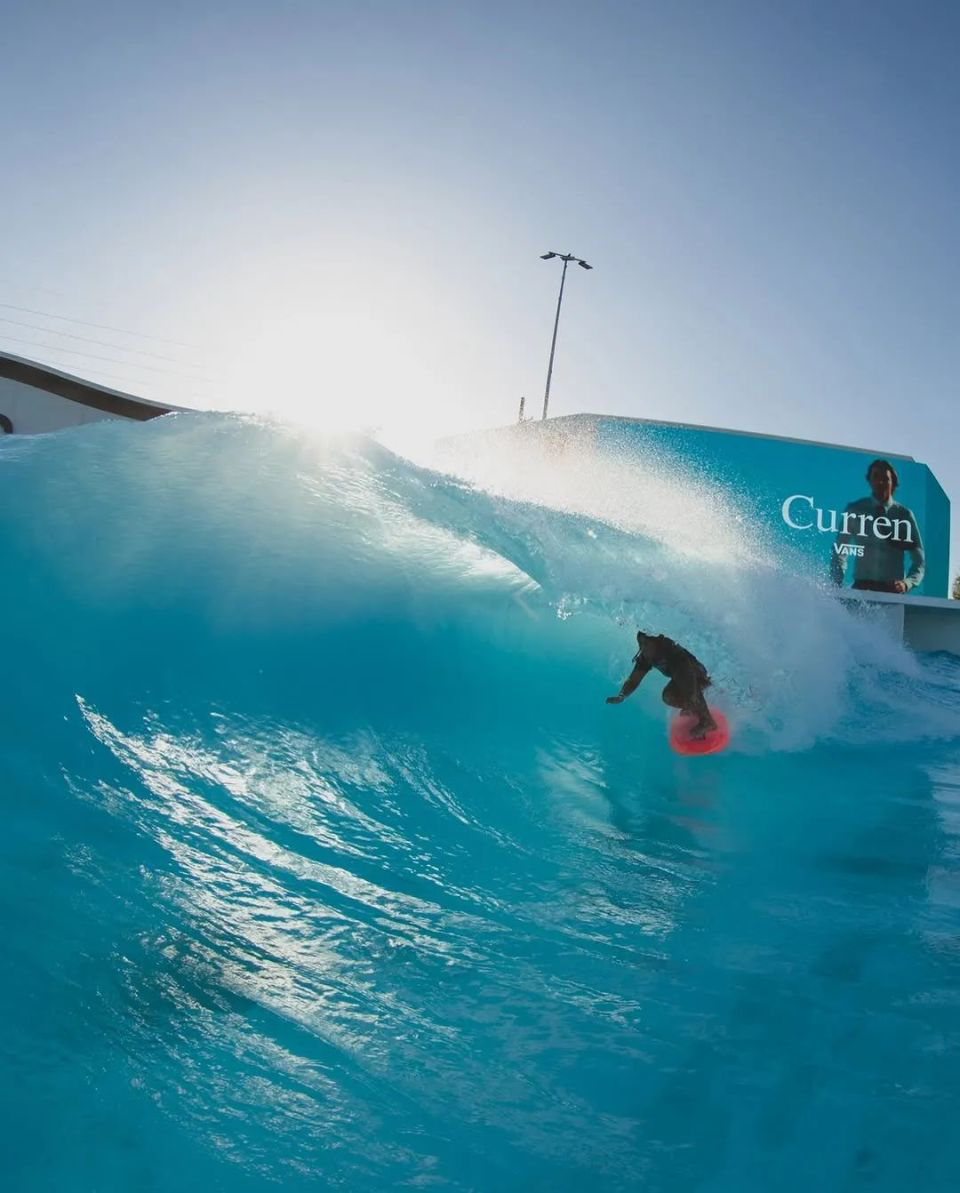

In [6]:
Image.open(img_paths[0])

In [7]:
img_captions[0]

'一束花在森林在跑步，模糊背景。'

# 加载CLIP模型

In [8]:
from PIL import Image
import requests
from transformers import ChineseCLIPProcessor, ChineseCLIPModel
import torch

# 官方 openai clip 不支持中文
# https://www.modelscope.cn/models/AI-ModelScope/chinese-clip-vit-base-patch16
model = ChineseCLIPModel.from_pretrained("./model/chinese-clip-vit-base-patch16") # 中文clip模型
processor = ChineseCLIPProcessor.from_pretrained("./model/chinese-clip-vit-base-patch16") # 预处理

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


# 图像编码

In [9]:
img_image_feat = []

batch_size = 20
for idx in tqdm_notebook(range(len(img_captions) // batch_size + 1)):
    imgs = [ Image.open(path) for path in img_paths[idx*batch_size: (idx+1)*batch_size] ]
    
    if len(imgs) == 0:
        break
    
    inputs = processor(images=imgs, return_tensors="pt")
    with torch.no_grad():
        image_features = model.get_image_features(**inputs)
        image_features = image_features.data.numpy()
        img_image_feat.append(image_features)

    break
        
img_image_feat = np.vstack(img_image_feat)
img_image_feat = normalize(img_image_feat)

C:\Users\Admin\AppData\Local\Temp\ipykernel_14252\2441136177.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for idx in tqdm_notebook(range(len(img_captions) // batch_size + 1)):


  0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
img_image_feat.shape # 20张图片 512 维度

(12, 512)

# 文本编码

In [11]:
img_texts_feat = []

batch_size = 20
for idx in tqdm_notebook(range(len(img_captions) // batch_size + 1)):
    texts = [ text for text in img_captions[idx*batch_size: (idx+1)*batch_size] ]

    if len(texts) == 0:
        break
    
    inputs = processor(text=texts, return_tensors="pt", padding=True)


    #with torch.no_grad():
        #text_features = model.get_text_features(**inputs)
        #image_features = image_features.data.numpy()
        #img_image_feat.append(image_features)



    with torch.no_grad():
        text_outputs = model.text_model(
            input_ids=inputs['input_ids'],
            attention_mask=inputs.get('attention_mask'),
            token_type_ids=inputs.get('token_type_ids'),
            position_ids=inputs.get('position_ids')
        )
        # 取 [CLS] 向量（序列第一个位置）
        cls_embedding = text_outputs.last_hidden_state[:, 0, :]   # (batch_size, hidden_size)
        print(cls_embedding)
        # 应用投影层
        text_features = model.text_projection(cls_embedding)


        text_features = text_features.data.numpy()
        img_texts_feat.append(text_features)
    break
        
img_texts_feat = np.vstack(img_texts_feat)
img_texts_feat = normalize(img_texts_feat)

C:\Users\Admin\AppData\Local\Temp\ipykernel_14252\2274358476.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for idx in tqdm_notebook(range(len(img_captions) // batch_size + 1)):


  0%|          | 0/1 [00:00<?, ?it/s]

TypeError: linear(): argument 'input' (position 1) must be Tensor, not NoneType

In [172]:
img_texts_feat.shape

(12, 512)

# 尝试1：相似度计算

In [173]:
query_idx = 11

sim_result = np.dot(img_texts_feat[query_idx], img_image_feat.T) # 矩阵计算
sim_idx = sim_result.argsort()[::-1][1:4]

输入文本:  黑白调的森林，一位老人在工作。


([], [])

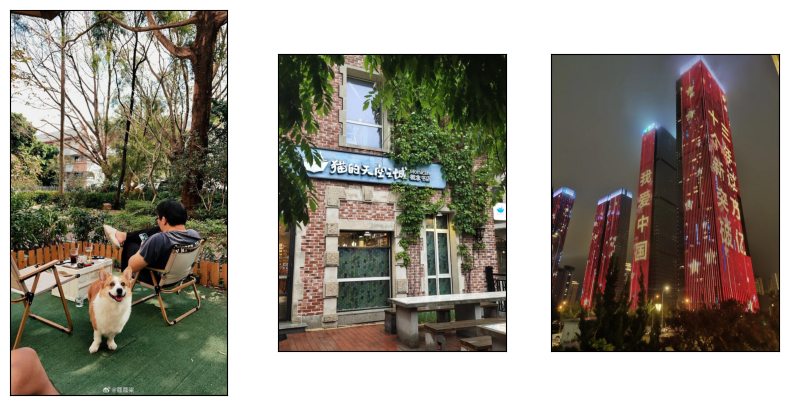

In [174]:
print('输入文本: ', img_captions[query_idx])

plt.figure(figsize=(10, 5))
plt.subplot(131)
plt.imshow(Image.open(img_paths[sim_idx[0]]))
plt.xticks([]); plt.yticks([])

plt.subplot(132)
plt.imshow(Image.open(img_paths[sim_idx[1]]))
plt.xticks([]); plt.yticks([])

plt.subplot(133)
plt.imshow(Image.open(img_paths[sim_idx[2]]))
plt.xticks([]); plt.yticks([])

In [176]:
query_idx = 11

sim_result = np.dot(img_image_feat[query_idx], img_texts_feat.T)
sim_idx = sim_result.argsort()[::-1][1:4]

文本识别结果:  ['一个右手拿着扇子的男人搂着一个弯着腰的女人站在干净的舞台上', '一个穿着裙子的女人站在背景板前的红地毯上', '一位女士抱着一个小孩子站在舞台上']


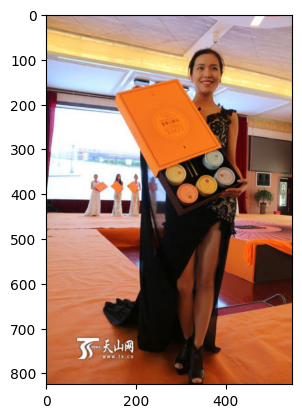

In [18]:
plt.imshow(Image.open(img_paths[query_idx]))

print('文本识别结果: ', [img_captions[x] for x in sim_idx])

# 文本标签编码

In [177]:
import jieba

In [178]:
jieba.lcut('今天天气很好，心情也很好。')

['今天天气', '很', '好', '，', '心情', '也', '很', '好', '。']

In [179]:
jieba.lcut(img_captions[0])

['一束花', '在', '森林', '在', '跑步', '，', '模糊', '背景', '。']

In [180]:
img_captions2words = [jieba.lcut(x) for x in img_captions]
img_captions2words = sum(img_captions2words, [])

In [181]:
img_captions2words[:10]

['一束花', '在', '森林', '在', '跑步', '，', '模糊', '背景', '。', '特写镜头']

In [182]:
img_captions2words = [x for x in img_captions2words if len(x) > 1]
img_captions2words = list(set(img_captions2words))

In [183]:
img_captions2words[:10]

['玩耍', '色彩鲜艳', '晒太阳', '一束花', '街道', '阳光明媚', '办公室', '周围', '海边', '一群']

In [184]:
img_texts_feat = []

batch_size = 20
for idx in tqdm_notebook(range(len(img_captions2words) // batch_size + 1)):
    texts = [ text for text in img_captions2words[idx*batch_size: (idx+1)*batch_size] ]

    if len(texts) == 0:
        break
    
    inputs = processor(text=texts, return_tensors="pt", padding=True)

    with torch.no_grad():
        text_features = model.get_text_features(**inputs)
        text_features = text_features.data.numpy()
        img_texts_feat.append(text_features)
        
img_texts_feat = np.vstack(img_texts_feat)
img_texts_feat = normalize(img_texts_feat)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13736\1150539393.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for idx in tqdm_notebook(range(len(img_captions2words) // batch_size + 1)):


  0%|          | 0/2 [00:00<?, ?it/s]

TypeError: linear(): argument 'input' (position 1) must be Tensor, not NoneType

# 尝试2：标签相似度计算

In [28]:
query_idx = 120

sim_result = np.dot(img_image_feat[query_idx], img_texts_feat.T)
sim_idx = sim_result.argsort()[::-1][1:7]

文本识别结果:  ['小姑娘', '稚嫩', '小女孩', '嬉笑', '里教', '淹没']


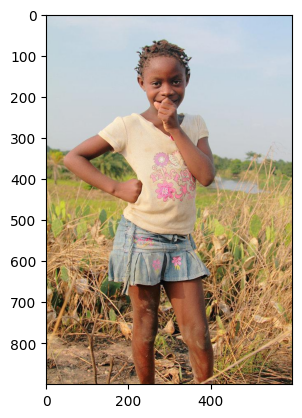

In [29]:
plt.imshow(Image.open(img_paths[query_idx]))

print('文本识别结果: ', [img_captions2words[x] for x in sim_idx])